# QTCAD M07 Valley Splitting — Result Analysis

- Device 12 — 1D MVEMT (Si/SiO2 우물) valley splitting
- SiGe Part 2 — TB 원자 구조 (원자 배치, 격자 구조, 조성 분포)

이 노트북은 `valleysplitting_1D_MVEMT.py`가 저장한 결과를 불러와 분석합니다.
이 스크립트는 실리콘 양자우물(quantum well)에 갇힌 전자의 **valley
splitting**을 multi-valley effective-mass theory(MVEMT)로 계산합니다.

벌크 실리콘의 전도대 최솟값은 $\langle 100 \rangle$ 방향을 따라 6개의 동등한
valley를 가집니다. 전자가 얇은 양자우물(여기서는 면외 전기장 $E$로 전자를
Si/SiO2 계면 쪽으로 눌러 형성)에 갇히면, 구속 방향(±z)의 두 valley가 날카로운
계면 potential에 의해 에너지가 갈라지는데, 이것이 실리콘 스핀/valley 큐비트에서
매우 중요한 valley splitting입니다 (valley splitting이 충분히 커야 낮은
valley-들뜬상태로의 leakage를 피할 수 있습니다).

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M07. Valley splitting\Reference`

분석 대상:
- `output/valley_splitting_qw_trivial.txt` — approx="trivial" (Bloch
  amplitude를 1로 설정)
- `output/valley_splitting_qw_ff.txt` — approx="ff" (form-factor 근사)
- `output/valley_splitting_qw_None.txt` — approx=None (Bloch amplitude를
  정확히 취급하는 완전 계산)
- `output/valley_splitting_vs_E.png` — 원본 스크립트가 저장한 비교 플롯
- `output/valley_wavefunctions.png` — 원본 스크립트가 저장한 valley별
  envelope wavefunction 플롯

주요 산출물:
1. 세 근사 수준의 valley splitting vs. 전기장 비교
2. 완전 계산 대비 상대 편차(%) 및 trivial/full 비율
3. 전기장에 대한 거듭제곱 스케일링(log-log fit)
4. 원본 PNG(비교 플롯, wavefunction 플롯) 재확인
5. 근사 수준별 계산 시간 (정확도-시간 비교)
6. 근사 수준별 물리적 차이 해석


---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼** — Device 12: Valley splitting (MVEMT)
  https://docs.nanoacademic.com/qtcad/tutorials/device/valleysplitting_1D_MVEMT/
- **QTCAD 공식 튜토리얼** — Atoms 2: Multiscale simulations of a SiGe-Si-SiGe QD, Part 2: Tight-binding model for valley splitting
  https://docs.nanoacademic.com/qtcad/tutorials/atoms/multiscale_2/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `valleysplitting_1D_MVEMT.py`, `01_mvemt_sige_well.py`, `02_tb_atoms_distribution.py`,
  `02b_plot_atoms_from_xyz.py`, `atoms_builder.py`, `atoms_plot.py` (M07/Reference)
---


In [1]:
# [동작] 기본 패키지 및 경로 설정
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M07. Valley splitting\Reference"
)
OUTPUT_DIR = BASE_DIR / "output"

FILE_TRIVIAL = OUTPUT_DIR / "valley_splitting_qw_trivial.txt"
FILE_FF = OUTPUT_DIR / "valley_splitting_qw_ff.txt"
FILE_NONE = OUTPUT_DIR / "valley_splitting_qw_None.txt"
FILE_PNG_VS_E = OUTPUT_DIR / "valley_splitting_vs_E.png"
FILE_PNG_WF = OUTPUT_DIR / "valley_wavefunctions.png"

EXPORT_DIR = OUTPUT_DIR
SAVE_FIGURES = True

print("BASE_DIR  :", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

assert BASE_DIR.exists(), f"Base directory가 없습니다:\n{BASE_DIR}"
assert OUTPUT_DIR.exists(), f"output 폴더가 없습니다:\n{OUTPUT_DIR}"

print("\n[OK] 기본 경로 확인 완료")

BASE_DIR  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M07. Valley splitting\Reference
OUTPUT_DIR: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M07. Valley splitting\Reference\output

[OK] 기본 경로 확인 완료


In [2]:
# [점검] 파일 inventory
expected_files = {
    "valley_splitting_qw_trivial.txt": FILE_TRIVIAL,
    "valley_splitting_qw_ff.txt": FILE_FF,
    "valley_splitting_qw_None.txt": FILE_NONE,
    "valley_splitting_vs_E.png": FILE_PNG_VS_E,
    "valley_wavefunctions.png": FILE_PNG_WF,
}

rows = []
for label, path in expected_files.items():
    rows.append({
        "file": label,
        "exists": path.exists(),
        "size_KB": path.stat().st_size / 1024 if path.exists() else np.nan,
        "path": str(path),
    })

inventory_df = pd.DataFrame(rows)
display(inventory_df)

missing = inventory_df.loc[~inventory_df["exists"], "file"].tolist()
if missing:
    print("\n[주의] 없는 파일:", missing)
else:
    print("\n[OK] 분석 대상 파일이 모두 존재합니다.")

,file,exists,size_KB,path
0,valley_splitting_qw_trivial.txt,True,0.498047,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
1,valley_splitting_qw_ff.txt,True,0.498047,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
2,valley_splitting_qw_None.txt,True,0.498047,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
3,valley_splitting_vs_E.png,True,126.789062,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
4,valley_wavefunctions.png,True,316.542969,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...



[OK] 분석 대상 파일이 모두 존재합니다.


## 1. 세 근사 수준의 valley splitting 데이터 로드

각 `valley_splitting_qw_*.txt`는 전기장 샘플마다 한 행씩, 2개 열
`[E-field (MV/m), valley splitting (eV)]`을 담은 순수 ASCII 표입니다
(원본 스크립트에서 `(d.energies[1] - d.energies[0]) / ct.e`로 저장).
근사 수준(`approx` 인자)의 의미는 QTCAD `multivalley_EMT` 모듈 문서에 따르면
다음과 같습니다:
- **trivial**: Bloch amplitude $u_\nu(\mathbf{r})=1$로 설정 (원자 스케일의
  주기적 성분을 완전히 무시).
- **ff** (form-factor): Bloch amplitude의 곱을 valley쌍에 의존하는 상수
  $a_0^{\nu\nu'}$로 근사.
- **None**: Bloch amplitude를 정확히(위치 의존성 그대로) 취급하는 완전 계산.

In [3]:
# [동작] 세 결과 파일 로드 (columns: E-field[MV/m], valley splitting[eV])
data_trivial = np.loadtxt(FILE_TRIVIAL)
data_ff = np.loadtxt(FILE_FF)
data_None = np.loadtxt(FILE_NONE)

assert np.allclose(data_trivial[:, 0], data_None[:, 0])
assert np.allclose(data_ff[:, 0], data_None[:, 0])

E_field = data_None[:, 0]
vs_full = data_None[:, 1]
vs_ff = data_ff[:, 1]
vs_trivial = data_trivial[:, 1]

vs_df = pd.DataFrame({
    "E_field_MVm": E_field,
    "trivial_meV": vs_trivial * 1e3,
    "ff_meV": vs_ff * 1e3,
    "full_meV": vs_full * 1e3,
})
display(vs_df.round(5))

,E_field_MVm,trivial_meV,ff_meV,full_meV
0,5.0,0.51316,0.10304,0.10490
1,10.0,1.02577,0.20629,0.21005
2,15.0,1.53803,0.30971,0.31541
3,20.0,2.04994,0.41327,0.42098
4,25.0,2.56159,0.51696,0.52670
5,30.0,3.07297,0.62078,0.63256
6,35.0,3.58409,0.72472,0.73860
7,40.0,4.09498,0.82879,0.84479
8,45.0,4.60566,0.93293,0.95109
9,50.0,5.11613,1.03722,1.05754


## 2. 근사 수준별 valley splitting vs. 전기장 비교

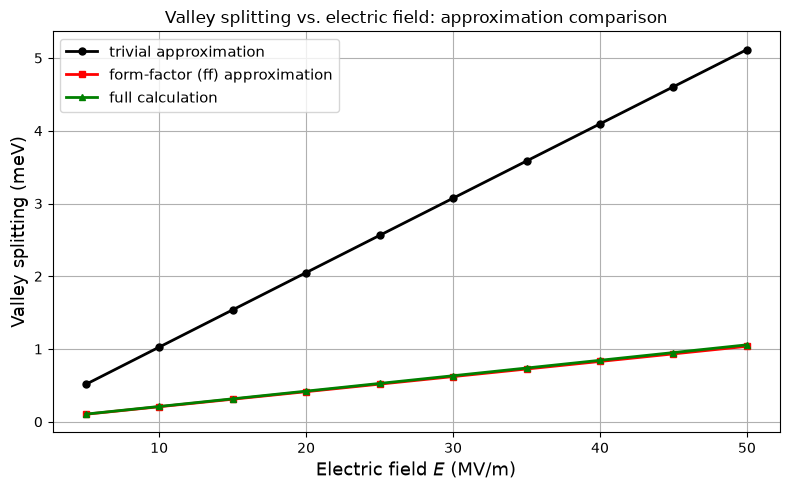


[해석] Full 계산(초록)과 form-factor 근사(빨강)는 거의 겹쳐 있는 반면, trivial 근사(검정)는 모든 전기장에서 약 5배 더 큽니다. Bloch amplitude를 1로 두면 +z/-z valley에 연관된 원자 스케일 진동 성분 사이의 destructive interference가 사라지는데, 이 간섭이 실제 결정에서 valley-coupling 행렬원소를 억제하는 핵심 요인이므로, trivial 근사는 valley splitting을 크게 과대평가합니다. Form-factor 근사는 이 억제 효과를 평균적으로 재현하는 상수로 유지하므로 훨씬 적은 계산 비용으로도 full 계산에 근접합니다.


In [4]:
# [실험] 세 근사 수준을 하나의 그래프에 겹쳐 그리기 (meV 단위)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(vs_df["E_field_MVm"], vs_df["trivial_meV"], "-ok",
        linewidth=2, markersize=5, label="trivial approximation")
ax.plot(vs_df["E_field_MVm"], vs_df["ff_meV"], "-sr",
        linewidth=2, markersize=5, label="form-factor (ff) approximation")
ax.plot(vs_df["E_field_MVm"], vs_df["full_meV"], "-^g",
        linewidth=2, markersize=5, label="full calculation")
ax.set_xlabel("Electric field $E$ (MV/m)", fontsize=13)
ax.set_ylabel("Valley splitting (meV)", fontsize=13)
ax.set_title("Valley splitting vs. electric field: approximation comparison")
ax.legend(fontsize=11)
ax.grid(True)
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(EXPORT_DIR / "analysis_valley_splitting_comparison.png", dpi=150)
plt.show()

print(
    "\n[해석] Full 계산(초록)과 form-factor 근사(빨강)는 거의 겹쳐 있는 반면, "
    "trivial 근사(검정)는 모든 전기장에서 약 5배 더 큽니다. Bloch amplitude를 "
    "1로 두면 +z/-z valley에 연관된 원자 스케일 진동 성분 사이의 destructive "
    "interference가 사라지는데, 이 간섭이 실제 결정에서 valley-coupling "
    "행렬원소를 억제하는 핵심 요인이므로, trivial 근사는 valley splitting을 "
    "크게 과대평가합니다. Form-factor 근사는 이 억제 효과를 평균적으로 재현하는 "
    "상수로 유지하므로 훨씬 적은 계산 비용으로도 full 계산에 근접합니다."
)

## 3. Full 계산 대비 상대 편차 정량화

In [5]:
# [점검] ff/trivial 근사의 full 대비 상대 편차(%) 및 trivial/full 비율 계산
rel_dev_ff = (vs_ff - vs_full) / vs_full * 100
rel_dev_trivial = (vs_trivial - vs_full) / vs_full * 100
ratio_trivial_full = vs_trivial / vs_full

dev_df = pd.DataFrame({
    "E_field_MVm": E_field,
    "ff_dev_pct": rel_dev_ff,
    "trivial_dev_pct": rel_dev_trivial,
    "trivial_over_full": ratio_trivial_full,
})
display(dev_df.round(3))

print(f"\nMean |ff deviation| from full     : {np.mean(np.abs(rel_dev_ff)):.3f} %")
print(f"Mean |trivial deviation| from full : {np.mean(np.abs(rel_dev_trivial)):.3f} %")
print(f"Mean trivial/full ratio            : {np.mean(ratio_trivial_full):.3f}")

print(
    "\n[해석] Form-factor 근사는 전체 전기장 범위에서 full 계산 대비 편차가 "
    "2% 미만으로, 훨씬 저렴한 비용으로도 production 용도에 쓸 수 있는 대체재임을 "
    "보여줍니다. Trivial 근사는 대략 4.85-4.9배 수준의 거의 전기장에 무관한 "
    "배율로 계속 과대평가하는데, 이 비율이 E에 거의 무관하게 일정하다는 점은 "
    "Bloch amplitude 간섭 누락이 (적어도 이 전기장 범위에서는) leading-order "
    "행렬원소에 대해 대략 곱셈적(multiplicative)이고 전기장에 무관한 보정으로 "
    "작용함을 시사합니다."
)

,E_field_MVm,ff_dev_pct,trivial_dev_pct,trivial_over_full
0,5.0,-1.771,389.205,4.892
1,10.0,-1.790,388.348,4.883
2,15.0,-1.808,387.629,4.876
3,20.0,-1.833,386.942,4.869
4,25.0,-1.848,386.349,4.863
5,30.0,-1.863,385.795,4.858
6,35.0,-1.880,385.252,4.853
7,40.0,-1.894,384.734,4.847
8,45.0,-1.909,384.250,4.842
9,50.0,-1.921,383.775,4.838



Mean |ff deviation| from full     : 1.852 %
Mean |trivial deviation| from full : 386.228 %
Mean trivial/full ratio            : 4.862

[해석] Form-factor 근사는 전체 전기장 범위에서 full 계산 대비 편차가 2% 미만으로, 훨씬 저렴한 비용으로도 production 용도에 쓸 수 있는 대체재임을 보여줍니다. Trivial 근사는 대략 4.85-4.9배 수준의 거의 전기장에 무관한 배율로 계속 과대평가하는데, 이 비율이 E에 거의 무관하게 일정하다는 점은 Bloch amplitude 간섭 누락이 (적어도 이 전기장 범위에서는) leading-order 행렬원소에 대해 대략 곱셈적(multiplicative)이고 전기장에 무관한 보정으로 작용함을 시사합니다.


## 4. 전기장에 대한 valley splitting의 스케일링

In [6]:
# [점검] log-log 선형 fit으로 거듭제곱 지수(splitting ~ E^p) 추출
log_E = np.log10(E_field)
p_full, logA_full = np.polyfit(log_E, np.log10(vs_full), 1)
p_trivial, logA_trivial = np.polyfit(log_E, np.log10(vs_trivial), 1)
p_ff, logA_ff = np.polyfit(log_E, np.log10(vs_ff), 1)

scaling_df = pd.DataFrame({
    "approximation": ["full", "ff", "trivial"],
    "power_exponent_p": [p_full, p_ff, p_trivial],
})
display(scaling_df.round(4))

print(
    "\n[해석] 세 근사 모두 이 범위(5-50 MV/m)에서 valley splitting이 전기장에 "
    "거의 선형(p ~ 1)으로 비례합니다. 날카로운 계면이 하나뿐인 삼각형 우물에서는 "
    "전기장이 클수록 파동함수가 계면에 더 세게 눌려, 계면에서의 envelope 크기와 "
    "그 기울기가 E에 비례해 커지고 valley-coupling 행렬원소도 E에 비례합니다 "
    "(Gamble et al. APL 2016, Fig. S1과 같은 결과). 비단조 진동은 우물이 얇고 "
    "계면이 두 개일 때 두 계면의 기여가 간섭하면서 나타나는 현상으로, "
    "이 계산(계면 1개)과는 관계가 없습니다."
)


,approximation,power_exponent_p
0,full,1.0036
1,ff,1.0029
2,trivial,0.9987



[해석] 세 근사 모두 이 범위(5-50 MV/m)에서 valley splitting이 전기장에 거의 선형(p ~ 1)으로 비례합니다. 날카로운 계면이 하나뿐인 삼각형 우물에서는 전기장이 클수록 파동함수가 계면에 더 세게 눌려, 계면에서의 envelope 크기와 그 기울기가 E에 비례해 커지고 valley-coupling 행렬원소도 E에 비례합니다 (Gamble et al. APL 2016, Fig. S1과 같은 결과). 비단조 진동은 우물이 얇고 계면이 두 개일 때 두 계면의 기여가 간섭하면서 나타나는 현상으로, 이 계산(계면 1개)과는 관계가 없습니다.


## 5. 원본 스크립트가 저장한 PNG 확인

원본 스크립트는 데이터 테이블 외에 두 개의 그림을 직접 저장했습니다: 위에서
재구성한 비교 플롯과 동등한 그림, 그리고 완전 계산의 valley별 wavefunction
envelope 플롯입니다. 교차 검증을 위해 두 원본 이미지를 그대로 표시합니다.

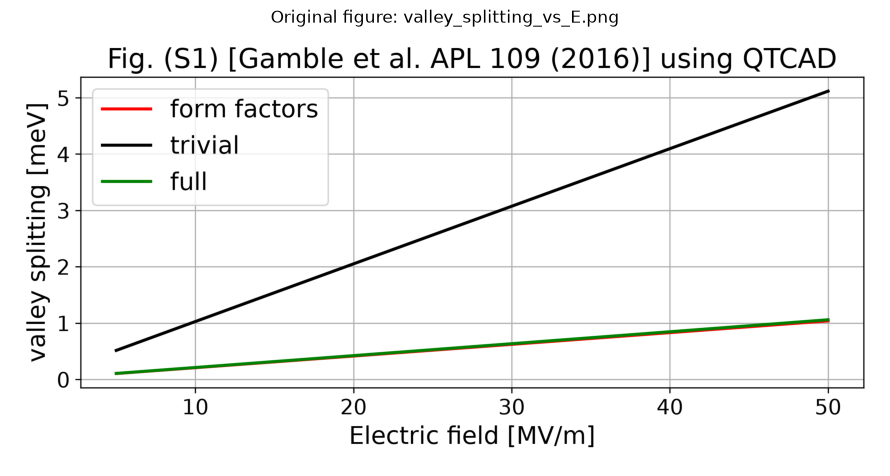

In [7]:
# [실험] valley_splitting_vs_E.png 표시 (원본 스크립트의 plot_vs 결과, 교차 검증용)
img_vs_E = mpimg.imread(FILE_PNG_VS_E)
fig, ax = plt.subplots(figsize=(9, 5))
ax.imshow(img_vs_E)
ax.axis("off")
ax.set_title("Original figure: valley_splitting_vs_E.png")
fig.tight_layout()
plt.show()

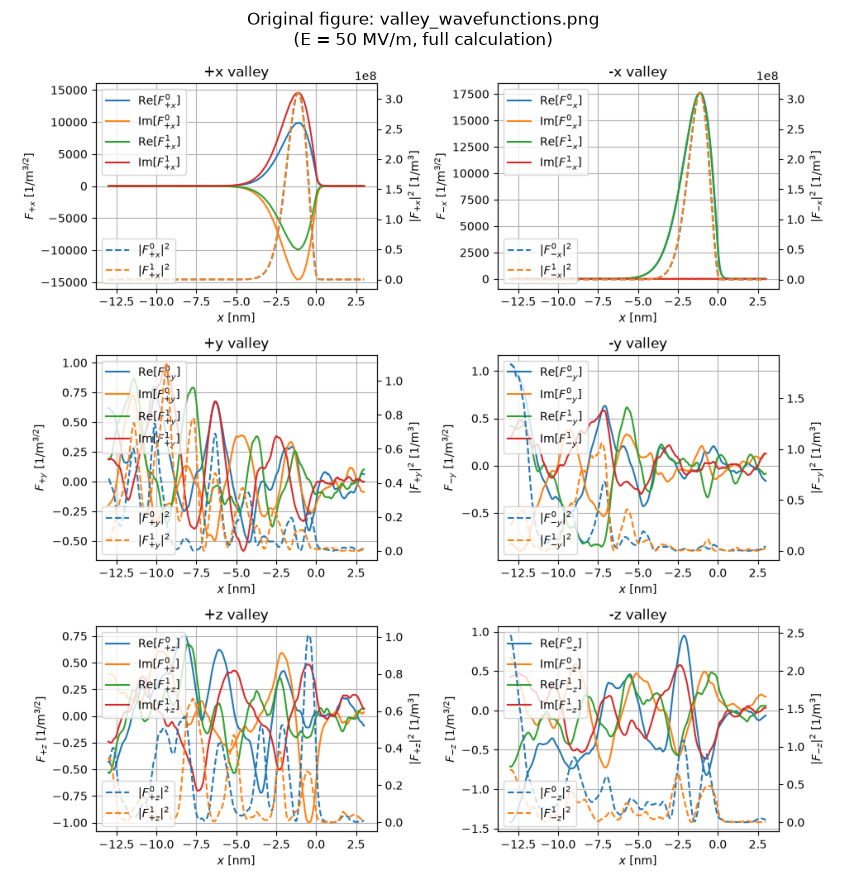


[해석] 1D 메시의 좌표축은 x이므로 구속(전기장·계면) 방향도 x입니다. 그림에서 envelope가 큰 것은 ±x valley(진폭 ~1e4 m^-3/2)이고, ±y·±z valley는 진폭 ~1 수준의 수치 잡음입니다. 즉 구속 방향과 나란한 두 valley만 valley-splitting 물리에 관여하며, 실제 Si/SiGe 소자에서 성장축(z)의 ±z valley가 하는 역할을 여기서는 ±x valley가 합니다. +x valley의 Re/Im이 E0와 E1에서 부호가 다른 것은 두 valley 상태가 ±x 성분의 서로 다른 위상 조합(결합/반결합)임을 보여줍니다.


In [8]:
# [실험] valley_wavefunctions.png 표시 (E=50 MV/m, full 계산의 6-valley envelope)
img_wf = mpimg.imread(FILE_PNG_WF)
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(img_wf)
ax.axis("off")
ax.set_title("Original figure: valley_wavefunctions.png\n(E = 50 MV/m, full calculation)")
fig.tight_layout()
plt.show()

print(
    "\n[해석] 1D 메시의 좌표축은 x이므로 구속(전기장·계면) 방향도 x입니다. "
    "그림에서 envelope가 큰 것은 ±x valley(진폭 ~1e4 m^-3/2)이고, ±y·±z valley는 "
    "진폭 ~1 수준의 수치 잡음입니다. 즉 구속 방향과 나란한 두 valley만 "
    "valley-splitting 물리에 관여하며, 실제 Si/SiGe 소자에서 성장축(z)의 ±z valley가 "
    "하는 역할을 여기서는 ±x valley가 합니다. +x valley의 Re/Im이 E0와 E1에서 "
    "부호가 다른 것은 두 valley 상태가 ±x 성분의 서로 다른 위상 조합(결합/반결합)임을 보여줍니다."
)


## 6. 근사 수준별 계산 시간

정확도만으로는 근사를 고를 수 없으므로, 근사 수준별 1점당 MVEMT 풀이 시간을
비교합니다. 수정된 스크립트로 재실행했다면 `output/valley_splitting_timing.txt`를,
없다면 `valleysplitting_run3.log`의 `solved in ... s` 30개를 스크립트 루프 순서
(trivial 10점 → ff 10점 → full 10점)대로 읽습니다.


timing source: valleysplitting_run3.log


,mean,median,min,max,mean_abs_err_pct,speedup_vs_full(median)
approx,,,,,,
trivial,29.40,28.32,19.57,41.74,386.23,4.86
ff,88.02,49.52,38.92,235.02,1.85,2.78
full,118.27,137.60,26.22,203.54,0.00,1.00


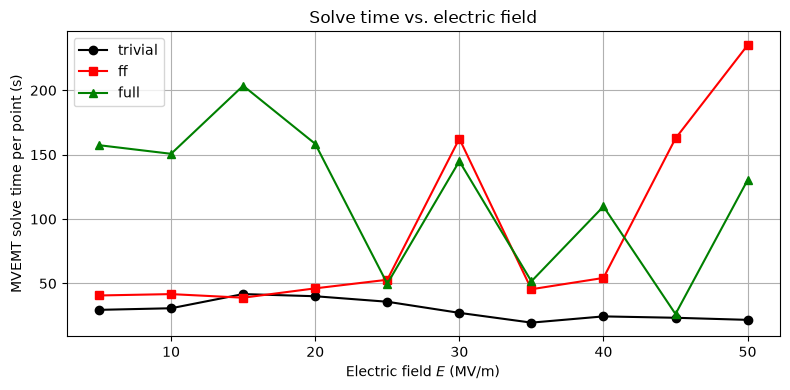


[해석] 중앙값 기준으로 ff 근사가 full보다 몇 배 빠른지, 그리고 그 대가로 평균 오차가 몇 %인지가 이 표의 결론입니다. 이후 Study의 파라미터 스윕은 full 대신 ff 근사를 기본값으로 씁니다. 같은 근사 안에서도 시간이 수 배씩 흔들리면(예: 같은 E에서 40 s와 160 s) 반복 고유값 풀이의 수렴 횟수 차이나 PC 부하 영향이므로, 미팅용 수치는 중앙값으로 보고합니다.


In [9]:
# [점검] 근사 수준별 1점당 풀이 시간
import re

FILE_TIMING = OUTPUT_DIR / "valley_splitting_timing.txt"
FILE_LOG = BASE_DIR / "valleysplitting_run3.log"

if FILE_TIMING.exists():
    timing_df = pd.read_csv(FILE_TIMING, sep="\t", header=None,
                            names=["approx", "E_field_MVm", "time_s"])
    timing_df["approx"] = timing_df["approx"].replace({"None": "full"})
    source = FILE_TIMING.name
else:
    text = FILE_LOG.read_text(encoding="utf-8", errors="ignore")
    times = [float(t) for t in re.findall(r"solved in ([0-9.]+) s", text)]
    assert len(times) == 30, f"solve 횟수가 30이 아닙니다: {len(times)}"
    timing_df = pd.DataFrame({
        "approx": ["trivial"] * 10 + ["ff"] * 10 + ["full"] * 10,
        "E_field_MVm": list(E_field) * 3,
        "time_s": times,
    })
    source = FILE_LOG.name

time_summary = timing_df.groupby("approx", sort=False)["time_s"].agg(
    ["mean", "median", "min", "max"]).reindex(["trivial", "ff", "full"])
err_map = {"trivial": np.mean(np.abs(rel_dev_trivial)),
           "ff": np.mean(np.abs(rel_dev_ff)), "full": 0.0}
time_summary["mean_abs_err_pct"] = time_summary.index.map(err_map)
time_summary["speedup_vs_full(median)"] = (
    time_summary.loc["full", "median"] / time_summary["median"])
print("timing source:", source)
display(time_summary.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
for name, mk in [("trivial", "-ok"), ("ff", "-sr"), ("full", "-^g")]:
    sub = timing_df[timing_df["approx"] == name]
    ax.plot(sub["E_field_MVm"], sub["time_s"], mk, label=name)
ax.set_xlabel("Electric field $E$ (MV/m)")
ax.set_ylabel("MVEMT solve time per point (s)")
ax.set_title("Solve time vs. electric field")
ax.legend(); ax.grid(True)
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(EXPORT_DIR / "analysis_solve_time.png", dpi=150)
plt.show()

print(
    "\n[해석] 중앙값 기준으로 ff 근사가 full보다 몇 배 빠른지, 그리고 그 대가로 "
    "평균 오차가 몇 %인지가 이 표의 결론입니다. 이후 Study의 파라미터 스윕은 "
    "full 대신 ff 근사를 기본값으로 씁니다. 같은 근사 안에서도 시간이 수 배씩 "
    "흔들리면(예: 같은 E에서 40 s와 160 s) 반복 고유값 풀이의 수렴 횟수 차이나 "
    "PC 부하 영향이므로, 미팅용 수치는 중앙값으로 보고합니다."
)


## 7. SiGe Part 2 (tight-binding) 원자 구조 분석


위 1~6절의 MVEMT 분석은 원자를 다루지 않고 envelope만 풉니다. 원자 하나하나의 배치는
**SiGe Part 2 튜토리얼(`multiscale_2.py`)** 이 만든 원자 구조에서 봅니다.
이 튜토리얼은 SiGe 장벽을 Si 70 % / Ge 30 % 무작위 합금으로 채우고(`rng_seed=104`),
우물 상·하부 계면을 `RoughSurface`(Hurst 0.3, rms 0.5 nm)로 거칠게 만든 뒤
Keating 모델로 격자를 이완하고, 결과를 `output/multiscale.xyz`로 저장합니다.

**필요 파일** (SiGe Part 2 튜토리얼 `multiscale_2.py`를 M01 Reference에서 먼저 실행하면 생김)
- `01. SiGe One QD_part.1/Reference/output/multiscale.xyz` — 원자 종과 이완된 좌표 (필수, M01/M07이 공유)

**분석 항목**
1. 원자층 검출과 층별 Ge 조성 프로파일 → 실제 계면 위치와 계면 폭
2. 원자 배치도: 측면 단면, 원자층 평면, 계면 부근 Ge 3D
3. 격자 구조: 계면 격자 확대도(결합선), 결합 길이 분포, 원자층 간격(변형)
4. 스페이서 국소 조성 지도와 이항분포 비교
5. 양자점 영역 원자 구성, TB 결과값(VS 등) 정답지 대조

`multiscale.xyz`가 없으면 아래 셀은 안내만 출력하고 건너뜁니다.


In [10]:
# [동작] 원자 구조(SiGe Part 2) 설정 및 multiscale.xyz 로드
TB_DIR = BASE_DIR.parent.parent / "01. SiGe One QD_part.1" / "Reference"
TB_OUT = TB_DIR / "output"
FILE_XYZ = TB_OUT / "multiscale.xyz"
FILE_PARAMS = TB_OUT / "multiscale_params.txt"
FILE_ROUGH_2D = TB_OUT / "multiscale_rough_2d.png"
FILE_ROUGH_3D = TB_OUT / "multiscale_rough_3d.png"
TB_EXPORT = TB_OUT                       # 분석 그림 저장 위치

# 튜토리얼 구조 파라미터 (multiscale_2.py와 동일)
WELL_TOP_NM, WELL_BOT_NM = -35.0, -38.0  # RoughSurface 평균 높이
ROUGH_RMS_NM = 0.5
X_GE = 0.30
QD_BOX_NM = {"x": (-8.0, 8.0), "y": (-8.0, 8.0), "z": (-40.0, -33.0)}  # SubAtoms 상자
XYZ_UNIT = "auto"                        # "auto" / "angstrom" / "nm" / "m"

# 참고 상수
A_SI, A_GE = 0.5431, 0.5658              # 격자상수 (nm)
A_SIGE = A_SI + X_GE * (A_GE - A_SI)     # Vegard 법칙
SI_COLOR, GE_COLOR = "#7aa6d8", "#d1453b"

TB_READY = FILE_XYZ.exists()
if not TB_READY:
    print(f"[대기] {FILE_XYZ}\n가 없습니다. 01. SiGe One QD_part.1/Reference에서 multiscale_2.py를 "
          "먼저 실행하세요. 아래 셀은 건너뜁니다.")
else:
    import time as _time
    _t0 = _time.perf_counter()
    with open(FILE_XYZ, encoding="utf-8", errors="ignore") as f:
        n_atoms = int(f.readline().split()[0])
        xyz_comment = f.readline().strip()
    _df = pd.read_csv(FILE_XYZ, sep=r"\s+", skiprows=2, header=None, nrows=n_atoms,
                      usecols=[0, 1, 2, 3], engine="c")
    species = _df[0].astype(str).str.strip().to_numpy()
    _xyz = _df[[1, 2, 3]].to_numpy(dtype=float)
    del _df

    # 단위 판정: 튜토리얼 z는 -50 ~ -5 nm → |좌표| 최대가 ~1e-8이면 m, 수십이면 nm, 수백이면 Å
    _span = np.abs(_xyz).max()
    xyz_unit = XYZ_UNIT if XYZ_UNIT != "auto" else (
        "m" if _span < 1e-6 else ("nm" if _span < 150 else "angstrom"))
    pos = _xyz * {"m": 1e9, "nm": 1.0, "angstrom": 0.1}[xyz_unit]   # nm
    del _xyz
    is_ge = species == "Ge"

    print(f"파일          : {FILE_XYZ.name} ({FILE_XYZ.stat().st_size/1e6:.1f} MB, "
          f"{_time.perf_counter()-_t0:.1f} s)")
    print(f"원자 수       : {len(species):,} (튜토리얼 문서: 896,337)")
    print(f"원자 종       : {dict(zip(*np.unique(species, return_counts=True)))}")
    print(f"좌표 단위     : |좌표| 최대 {_span:.3g} → '{xyz_unit}'로 판정")
    print("범위 (nm)     : x {:.2f}~{:.2f}, y {:.2f}~{:.2f}, z {:.2f}~{:.2f}".format(
        *[v for k in range(3) for v in (pos[:, k].min(), pos[:, k].max())]))
    print(f"전체 Ge 비율  : {is_ge.mean()*100:.2f} %")

파일          : multiscale.xyz (51.7 MB, 0.9 s)
원자 수       : 896,337 (튜토리얼 문서: 896,337)
원자 종       : {'Ge': np.int64(251381), 'Si': np.int64(644956)}
좌표 단위     : |좌표| 최대 502 → 'angstrom'로 판정
범위 (nm)     : x -10.05~10.04, y -10.05~10.05, z -50.23~-4.76
전체 Ge 비율  : 28.05 %


In [11]:
# [동작] Part B 분석 함수 정의 (원자층 검출, 배치도, 결합 분석)
from matplotlib.colors import ListedColormap


def find_layers(z, gap=0.04):
    """z 좌표를 원자층으로 묶는다. 정렬한 z에서 간격이 gap(nm)보다 크면 다른 층.
    [001] 층 간격은 약 0.136 nm, Keating 이완 후 층 안의 흔들림은 0.01 nm 수준이라
    gap = 0.04 nm로 구분된다. 고정 폭 빈은 SiGe 층이 늘어난 만큼 누적 오차가 생겨 쓰지 않는다."""
    order = np.argsort(z, kind="stable")
    zs = z[order]
    brk = np.concatenate([[0], np.where(np.diff(zs) > gap)[0] + 1, [len(zs)]])
    layer_id = np.empty(len(z), dtype=np.int64)
    for k in range(len(brk) - 1):
        layer_id[order[brk[k]:brk[k + 1]]] = k
    n = np.bincount(layer_id)
    z_mean = np.bincount(layer_id, weights=z) / n
    z_std = np.sqrt(np.maximum(np.bincount(layer_id, weights=z**2) / n - z_mean**2, 0))
    return layer_id, z_mean, z_std, n


def crossing(zm, f, level, zlo, zhi, z0, smooth=5):
    """zlo~zhi 구간에서 f(z)가 level을 지나는 z (선형 보간).
    층별 요동(이항분포) 때문에 생기는 가짜 교차를 줄이려고 smooth개 층 이동평균 후,
    교차점이 여러 개면 z0(평균 계면 높이)에 가장 가까운 것을 쓴다. 없으면 nan."""
    m = (zm >= zlo) & (zm <= zhi)
    z_, f_ = zm[m], f[m]
    if smooth > 1 and len(f_) > smooth:
        f_ = np.convolve(f_, np.ones(smooth) / smooth, mode="same")
        cut = smooth // 2
        z_, f_ = z_[cut:-cut], f_[cut:-cut]
    s = np.sign(f_ - level)
    idx = np.where(np.diff(s) != 0)[0]
    if len(idx) == 0:
        return np.nan
    zc = z_[idx] + (level - f_[idx]) * (z_[idx + 1] - z_[idx]) / (f_[idx + 1] - f_[idx])
    return float(zc[np.argmin(np.abs(zc - z0))])


def dot_size(n, base=12.0):
    return float(np.clip(base * 2000.0 / max(n, 1), 0.3, base))


def side_view(ax, sel, title):
    p, g = pos[sel], is_ge[sel]
    s = dot_size(len(p))
    ax.scatter(p[~g, 0], p[~g, 2], s=s, c=SI_COLOR, lw=0, label=f"Si ({(~g).sum():,})")
    ax.scatter(p[g, 0], p[g, 2], s=s, c=GE_COLOR, lw=0, label=f"Ge ({g.sum():,})")
    for zz in (WELL_TOP_NM, WELL_BOT_NM):
        ax.axhline(zz, color="k", ls="--", lw=0.8)
    ax.set_aspect("equal")
    ax.set_xlabel("x (nm)"); ax.set_ylabel("z (nm)")
    ax.set_title(title, fontsize=10)
    ax.legend(loc="upper right", markerscale=3, fontsize=8)


def layer_closest(z_target):
    k = int(np.argmin(np.abs(layer_z - z_target)))
    return layer_id == k, layer_z[k]


def neighbor_bonds(p, k=4, r_max=0.30):
    """각 원자의 최근접 k개 이웃 (거리 < r_max nm). (i, j, d) 반환, i < j로 중복 제거."""
    try:
        from scipy.spatial import cKDTree
        d, j = cKDTree(p).query(p, k=k + 1, distance_upper_bound=r_max)
        d, j = d[:, 1:], j[:, 1:]
        i = np.repeat(np.arange(len(p)), k).reshape(-1, k)
        ok = np.isfinite(d) & (j < len(p))
        i, j, d = i[ok], j[ok], d[ok]
    except ImportError:   # scipy가 없으면 작은 영역만 직접 계산
        assert len(p) <= 5000, "scipy가 없으면 원자 5,000개 이하 영역만 계산할 수 있습니다."
        dd = np.linalg.norm(p[:, None] - p[None], axis=-1)
        i, j = np.where((dd > 0) & (dd < r_max))
        d = dd[i, j]
    keep = i < j
    return i[keep], j[keep], d[keep]


print("[OK] 함수 정의 완료")

[OK] 함수 정의 완료


## 8. 원자층별 Ge 조성 프로파일과 실제 계면 위치

원자를 [001] 원자층 단위로 묶어 층마다 Ge 비율을 구합니다.
- 장벽 층은 30 % 주변에서 **이항분포 요동** $\sigma=\sqrt{x(1-x)/N}$ 만큼 흔들려야 합니다
  (N = 층의 원자 수). 이보다 훨씬 크게 흔들리면 무작위 배치가 아닙니다.
- 계면은 거칠기(rms 0.5 nm) 때문에 층 평균으로 보면 계단이 아니라 몇 층에 걸쳐
  완만하게 바뀝니다. Ge 비율(5개 층 이동평균)이 장벽 값의 10 %·50 %·90 %를 지나는
  높이로 **실제 계면 위치**와 **10–90 % 계면 폭**을 구합니다.

검출된 원자층 332개, 층당 원자 2,592~2,736개, 층 안 z 흔들림(std) 최대 8.2 pm
기대 층 수 ≈ z 범위 / (a/4) = 335 (Si 기준)

장벽 층 평균 Ge 30.07 % (목표 30 %), 층간 표준편차 0.92 % (이항분포 예상 0.88 %)


,z10_nm,z50_nm,z90_nm,width_10_90_nm,shift_from_mean_nm
top,-35.745,-35.169,-34.218,1.527,-0.169
bottom,-37.387,-38.105,-38.852,1.466,-0.105


실제 우물 두께 (50 % 지점 사이): 2.94 nm (설정 3.0 nm)
우물 중심부(계면에서 1 nm 안쪽) Ge 원자: 16 / 18,937


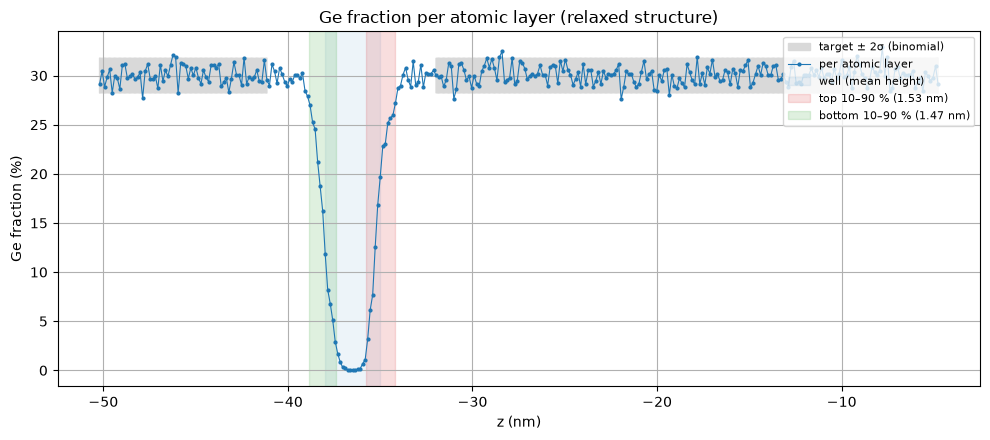


[해석] 확인할 점: (1) 장벽 층의 요동이 이항분포 예상과 비슷하면 Ge가 원자마다 독립적으로 무작위 배치된 것입니다. (2) 계면 10–90 % 폭은 원자 단위 계면은 계단이지만 거칠기(rms) 때문에 층 평균으로 넓어진 '유효 계면 폭'입니다. Part A의 MVEMT 계단 계면, Study 01의 tanh 계면 폭과 비교하는 기준값이 됩니다.


In [12]:
# [점검] 원자층 검출 + 층별 Ge 비율 + 계면 위치·폭
if TB_READY:
    layer_id, layer_z, layer_zstd, layer_n = find_layers(pos[:, 2])
    layer_ge = np.bincount(layer_id, weights=is_ge.astype(float)) / layer_n
    n_layers = len(layer_z)
    print(f"검출된 원자층 {n_layers}개, 층당 원자 {layer_n.min():,}~{layer_n.max():,}개, "
          f"층 안 z 흔들림(std) 최대 {layer_zstd.max()*1e3:.1f} pm")
    print(f"기대 층 수 ≈ z 범위 / (a/4) = {np.ptp(pos[:,2])/(A_SI/4):.0f} (Si 기준)")

    profile_df = pd.DataFrame({"z_nm": layer_z, "n_atoms": layer_n,
                               "Ge_frac": layer_ge, "z_std_pm": layer_zstd * 1e3})
    profile_df.to_csv(TB_EXPORT / "analysis_tb_z_profile.csv", index=False)

    # 장벽 영역(계면에서 3 nm 이상 떨어진 층)의 평균 조성과 요동
    barrier = (layer_z > WELL_TOP_NM + 3) | (layer_z < WELL_BOT_NM - 3)
    sig_exp = np.sqrt(X_GE * (1 - X_GE) / layer_n[barrier])
    print(f"\n장벽 층 평균 Ge {layer_ge[barrier].mean()*100:.2f} % (목표 {X_GE*100:.0f} %), "
          f"층간 표준편차 {layer_ge[barrier].std()*100:.2f} % "
          f"(이항분포 예상 {sig_exp.mean()*100:.2f} %)")

    # 계면 위치와 10–90 % 폭
    xb = layer_ge[barrier].mean()
    iface = {}
    for name, z0 in (("top", WELL_TOP_NM), ("bottom", WELL_BOT_NM)):
        zs = {lv: crossing(layer_z, layer_ge, lv * xb, z0 - 3.0, z0 + 3.0, z0) for lv in (0.1, 0.5, 0.9)}
        iface[name] = {"z10_nm": zs[0.1], "z50_nm": zs[0.5], "z90_nm": zs[0.9],
                       "width_10_90_nm": abs(zs[0.9] - zs[0.1]),
                       "shift_from_mean_nm": zs[0.5] - z0}
    iface_df = pd.DataFrame(iface).T
    display(iface_df.round(3))
    print(f"실제 우물 두께 (50 % 지점 사이): {iface['top']['z50_nm'] - iface['bottom']['z50_nm']:.2f} nm "
          f"(설정 {WELL_TOP_NM - WELL_BOT_NM:.1f} nm)")
    in_well = (pos[:, 2] < WELL_TOP_NM - 1.0) & (pos[:, 2] > WELL_BOT_NM + 1.0)
    print(f"우물 중심부(계면에서 1 nm 안쪽) Ge 원자: {is_ge[in_well].sum()} / {in_well.sum():,}")

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.fill_between(layer_z, (X_GE - 2 * np.sqrt(X_GE*(1-X_GE)/layer_n)) * 100,
                    (X_GE + 2 * np.sqrt(X_GE*(1-X_GE)/layer_n)) * 100,
                    where=barrier, color="0.85", label="target ± 2σ (binomial)")
    ax.plot(layer_z, layer_ge * 100, "o-", ms=2, lw=0.8, label="per atomic layer")
    ax.axvspan(WELL_BOT_NM, WELL_TOP_NM, color="tab:blue", alpha=0.08, label="well (mean height)")
    for name, c in (("top", "tab:red"), ("bottom", "tab:green")):
        ax.axvspan(iface[name]["z10_nm"], iface[name]["z90_nm"], color=c, alpha=0.15,
                   label=f"{name} 10–90 % ({iface[name]['width_10_90_nm']:.2f} nm)")
    ax.set_xlabel("z (nm)"); ax.set_ylabel("Ge fraction (%)")
    ax.set_title("Ge fraction per atomic layer (relaxed structure)")
    ax.legend(fontsize=8, loc="upper right"); ax.grid(True)
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(TB_EXPORT / "analysis_tb_z_profile.png", dpi=150)
    plt.show()

    print("\n[해석] 확인할 점: (1) 장벽 층의 요동이 이항분포 예상과 비슷하면 Ge가 원자마다 "
          "독립적으로 무작위 배치된 것입니다. (2) 계면 10–90 % 폭은 원자 단위 계면은 계단이지만 "
          "거칠기(rms) 때문에 층 평균으로 넓어진 '유효 계면 폭'입니다. Part A의 MVEMT 계단 계면, "
          "Study 01의 tanh 계면 폭과 비교하는 기준값이 됩니다.")

## 9. 원자 배치도 — 측면 단면과 원자층 평면

- **측면 단면 (x–z)**: y = 0 근처 0.3 nm 두께 슬라이스. 우물(파랑만)과 장벽(빨강 섞임),
  계면이 원자 단위로 들쭉날쭉한 모습이 보입니다.
- **원자층 평면 (x–y)**: 원자층 하나만 위에서 본 그림. 거친 계면 층에서는 같은 층 안에
  Si 영역과 SiGe 영역이 섬처럼 섞입니다.

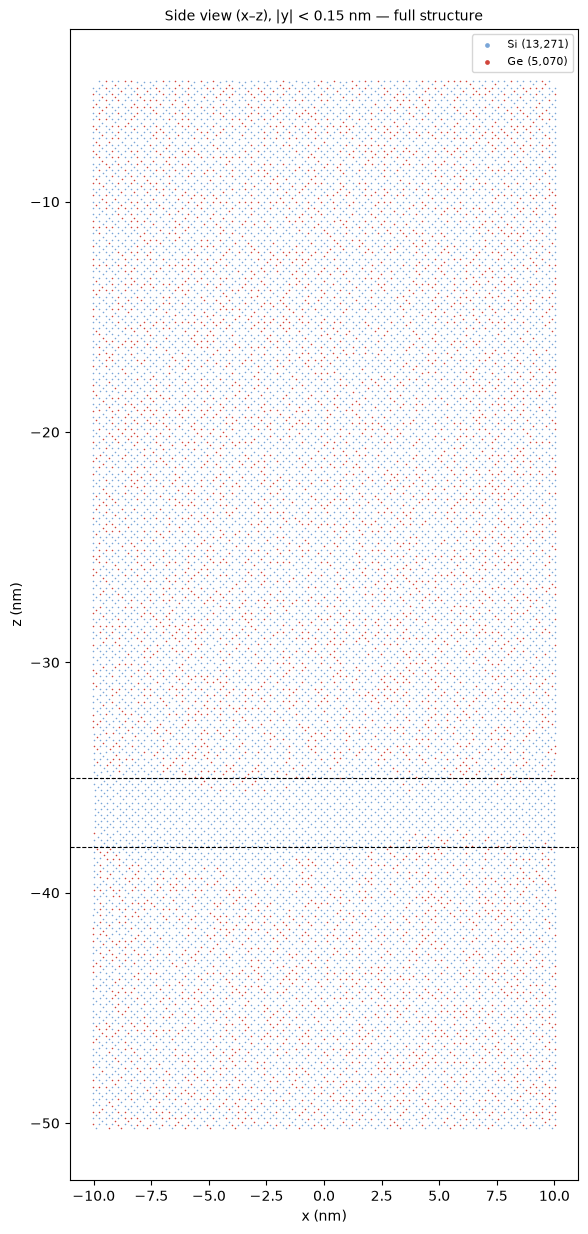

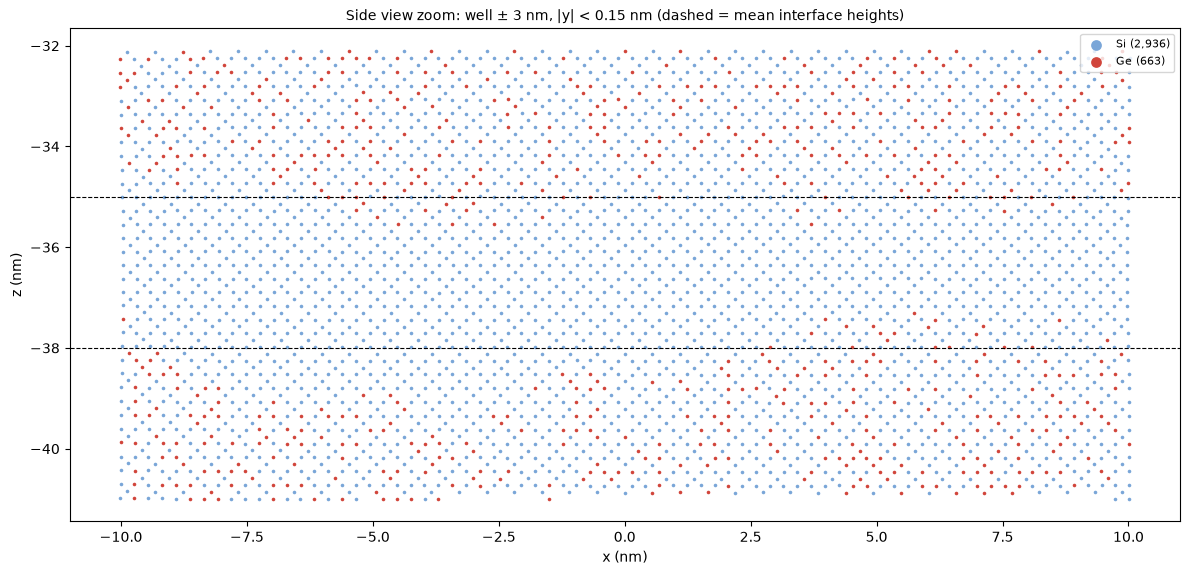

In [13]:
# [실험] 측면 단면 배치도 (전체 / 우물 ± 3 nm 확대)
if TB_READY:
    SLICE_NM = 0.3
    sl = np.abs(pos[:, 1]) < SLICE_NM / 2

    fig, ax = plt.subplots(figsize=(10, 10 * np.ptp(pos[:, 2]) / np.ptp(pos[:, 0]) * 0.55))
    side_view(ax, sl, f"Side view (x–z), |y| < {SLICE_NM/2:g} nm — full structure")
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(TB_EXPORT / "analysis_tb_side_full.png", dpi=200)
    plt.show()

    zw = (WELL_BOT_NM - 3, WELL_TOP_NM + 3)
    sel = sl & (pos[:, 2] > zw[0]) & (pos[:, 2] < zw[1])
    fig, ax = plt.subplots(figsize=(12, 12 * (zw[1] - zw[0]) / np.ptp(pos[:, 0]) * 1.05))
    side_view(ax, sel, f"Side view zoom: well ± 3 nm, |y| < {SLICE_NM/2:g} nm "
                       "(dashed = mean interface heights)")
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(TB_EXPORT / "analysis_tb_side_zoom.png", dpi=200)
    plt.show()

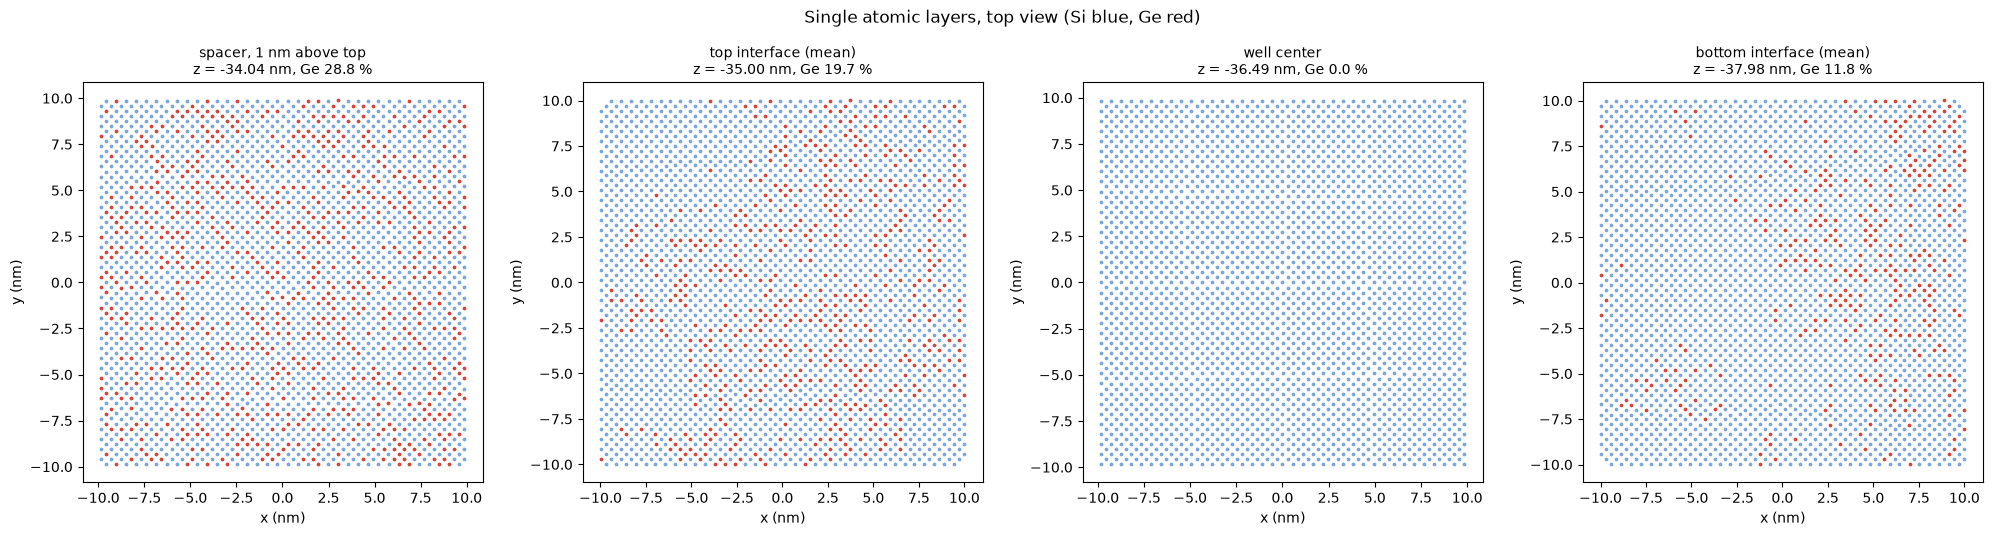

,layer,z_nm,n_atoms,Ge_pct
0,"spacer, 1 nm above top",-34.036,2664,28.754
1,top interface (mean),-34.998,2736,19.664
2,well center,-36.489,2665,0.000
3,bottom interface (mean),-37.978,2736,11.806


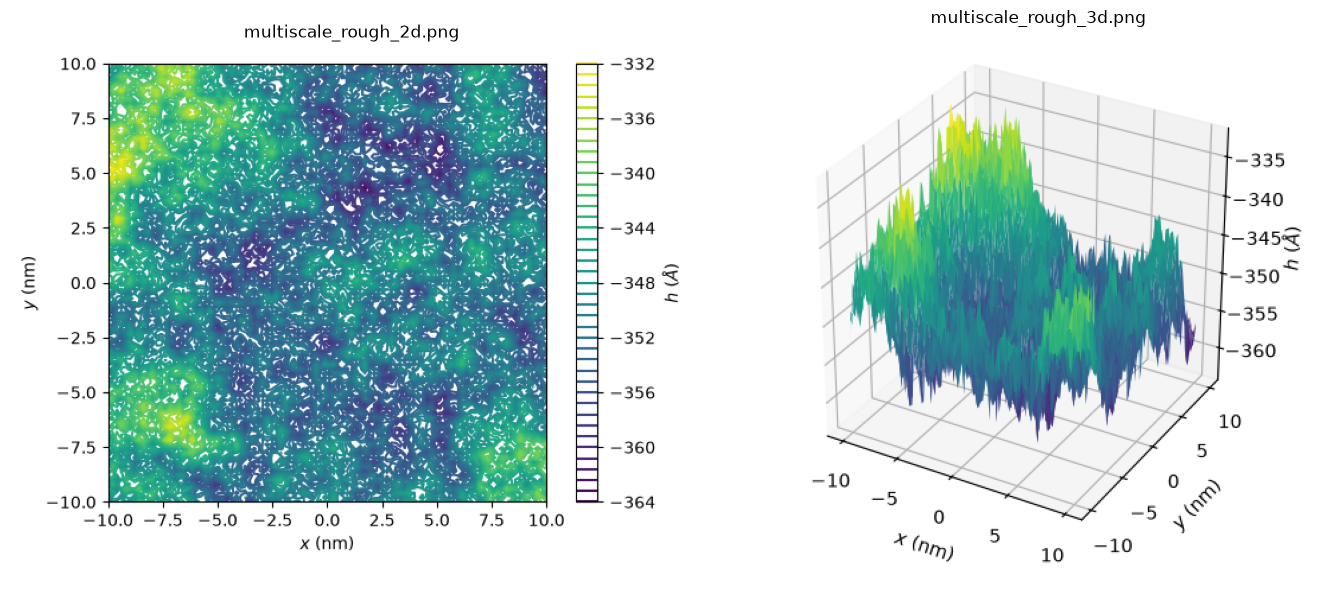


[해석] 계면 층 평면도에서 Si 섬과 SiGe 영역의 모양은 튜토리얼이 저장한 RoughSurface 2D 지도(위 그림)와 같은 패턴이어야 합니다. 그 높이 지도가 원자 배치로 어떻게 옮겨졌는지 확인하는 단계입니다.


In [14]:
# [실험] 원자층 평면 배치도 (스페이서 / 상부 계면 / 우물 중앙 / 하부 계면)
if TB_READY:
    targets = [("spacer, 1 nm above top", WELL_TOP_NM + 1.0),
               ("top interface (mean)", WELL_TOP_NM),
               ("well center", 0.5 * (WELL_TOP_NM + WELL_BOT_NM)),
               ("bottom interface (mean)", WELL_BOT_NM)]
    fig, axs = plt.subplots(1, 4, figsize=(20, 5.4))
    rows = []
    for ax, (label, zt) in zip(axs, targets):
        m, zl = layer_closest(zt)
        p, g = pos[m], is_ge[m]
        s = dot_size(len(p), base=10.0)
        ax.scatter(p[~g, 0], p[~g, 1], s=s, c=SI_COLOR, lw=0)
        ax.scatter(p[g, 0], p[g, 1], s=s, c=GE_COLOR, lw=0)
        ax.set_aspect("equal"); ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
        ax.set_title(f"{label}\nz = {zl:.2f} nm, Ge {g.mean()*100:.1f} %", fontsize=10)
        rows.append({"layer": label, "z_nm": zl, "n_atoms": len(p), "Ge_pct": g.mean() * 100})
    fig.suptitle("Single atomic layers, top view (Si blue, Ge red)")
    fig.subplots_adjust(left=0.04, right=0.99, bottom=0.1, top=0.85, wspace=0.25)
    if SAVE_FIGURES:
        fig.savefig(TB_EXPORT / "analysis_tb_top_layers.png", dpi=200)
    plt.show()
    display(pd.DataFrame(rows).round(3))

    if FILE_ROUGH_2D.exists():
        fig, axs = plt.subplots(1, 2, figsize=(14, 6))
        for ax, f_ in zip(axs, (FILE_ROUGH_2D, FILE_ROUGH_3D)):
            if f_.exists():
                ax.imshow(mpimg.imread(f_)); ax.set_title(f_.name)
            ax.axis("off")
        fig.tight_layout(); plt.show()

    print("\n[해석] 계면 층 평면도에서 Si 섬과 SiGe 영역의 모양은 튜토리얼이 저장한 "
          "RoughSurface 2D 지도(위 그림)와 같은 패턴이어야 합니다. 그 높이 지도가 원자 "
          "배치로 어떻게 옮겨졌는지 확인하는 단계입니다.")

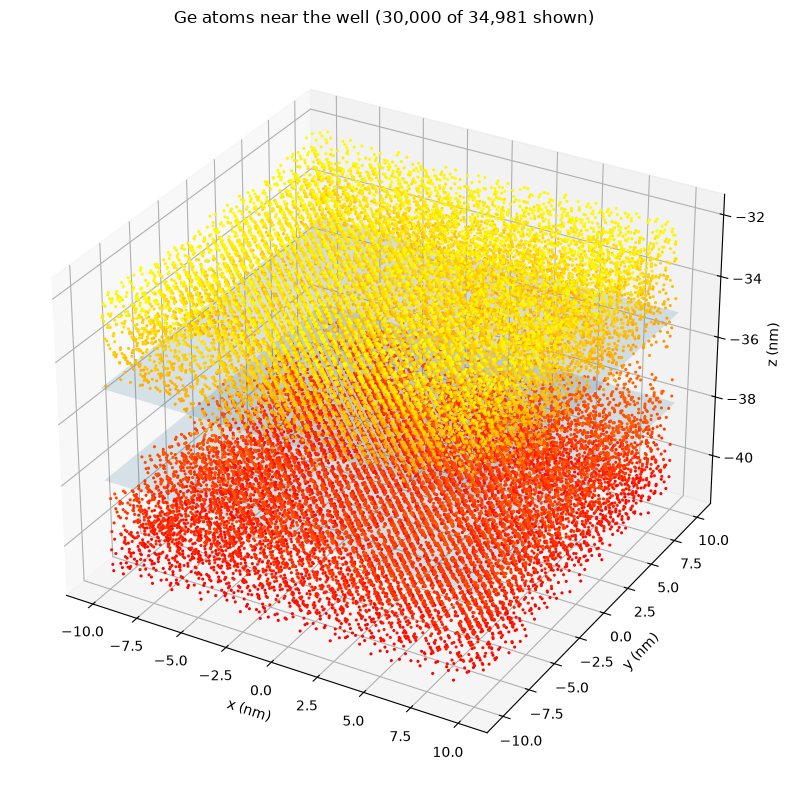

In [15]:
# [실험] 계면 부근 Ge 원자 3D 분포 (많으면 무작위로 솎아 표시)
if TB_READY:
    MAX_3D = 30000
    zw = (WELL_BOT_NM - 3, WELL_TOP_NM + 3)
    m = is_ge & (pos[:, 2] > zw[0]) & (pos[:, 2] < zw[1])
    p = pos[m]
    if len(p) > MAX_3D:
        p = p[np.random.default_rng(0).choice(len(p), MAX_3D, replace=False)]
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(projection="3d")
    ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=1.5, c=p[:, 2], cmap="autumn", depthshade=False)
    X, Y = np.meshgrid([pos[:, 0].min(), pos[:, 0].max()], [pos[:, 1].min(), pos[:, 1].max()])
    for zz in (WELL_TOP_NM, WELL_BOT_NM):
        ax.plot_surface(X, Y, np.full_like(X, zz), alpha=0.15, color="tab:blue")
    ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)"); ax.set_zlabel("z (nm)")
    ax.set_title(f"Ge atoms near the well ({len(p):,} of {m.sum():,} shown)")
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(TB_EXPORT / "analysis_tb_ge_3d.png", dpi=200)
    plt.show()

## 10. 격자 구조 — 계면 격자 확대도, 결합 길이, 원자층 간격

- **격자 확대도**: 상부 계면 2.5 × 2.5 nm 창을 [010] 방향으로 투영. 깊이 a(한 단위포) 안의
  원자와 최근접 결합(< 0.26 nm)을 그리면 다이아몬드 격자의 지그재그 결합이 보입니다.
  큰 점 = 앞쪽, 작은 점 = 뒤쪽.
- **결합 길이**: Keating 이완 후 결합 길이는 결합 종류에 따라 다릅니다.
  벌크 기준 Si–Si 0.2352 nm, Ge–Ge 0.2450 nm. 합금 안에서는 서로 끌려 그 사이 값이 됩니다.
- **원자층 간격**: 층 사이 z 간격이 Si 우물과 SiGe 장벽에서 다르면, 격자상수가 큰 SiGe
  층이 z 방향으로 늘어난 것(튜토리얼 VESTA 그림의 "부풂")입니다. 이것이 변형(strain)입니다.

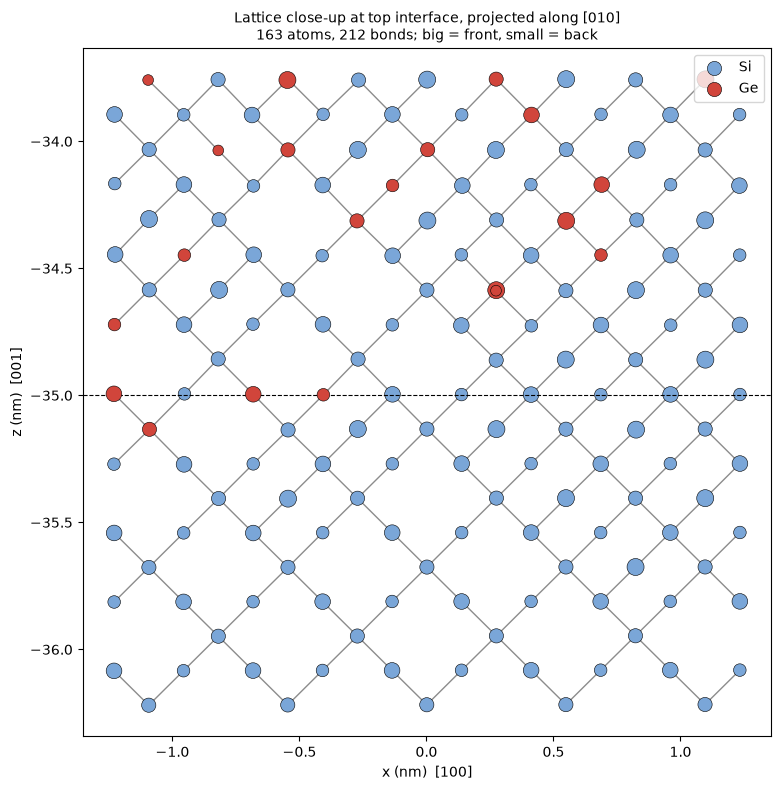

In [16]:
# [실험] 상부 계면 격자 확대도 (결합선 포함)
if TB_READY:
    W_NM, H_NM, DEPTH_NM = 2.5, 2.5, A_SI
    X0, Y0 = -W_NM / 2, 0.0
    m = ((pos[:, 0] >= X0) & (pos[:, 0] <= X0 + W_NM)
         & (np.abs(pos[:, 2] - WELL_TOP_NM) <= H_NM / 2)
         & (pos[:, 1] >= Y0) & (pos[:, 1] < Y0 + DEPTH_NM))
    p, g = pos[m], is_ge[m]
    bi, bj, bd = neighbor_bonds(p, r_max=0.26)

    fig, ax = plt.subplots(figsize=(8, 8 * H_NM / W_NM))
    for a_, b_ in zip(bi, bj):
        ax.plot(p[[a_, b_], 0], p[[a_, b_], 2], "-", color="0.55", lw=1.0, zorder=1)
    size = 60 + 90 * (1 - (p[:, 1] - Y0) / DEPTH_NM)
    ax.scatter(p[~g, 0], p[~g, 2], s=size[~g], c=SI_COLOR, edgecolors="k", lw=0.4, zorder=2, label="Si")
    ax.scatter(p[g, 0], p[g, 2], s=size[g], c=GE_COLOR, edgecolors="k", lw=0.4, zorder=3, label="Ge")
    ax.axhline(WELL_TOP_NM, color="k", ls="--", lw=0.8)
    ax.set_aspect("equal")
    ax.set_xlabel("x (nm)  [100]"); ax.set_ylabel("z (nm)  [001]")
    ax.set_title(f"Lattice close-up at top interface, projected along [010]\n"
                 f"{len(p)} atoms, {len(bi)} bonds; big = front, small = back", fontsize=10)
    ax.legend(loc="upper right")
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(TB_EXPORT / "analysis_tb_lattice_closeup.png", dpi=200)
    plt.show()

count  mean_pm  std_pm
region    type                         
barrier   Ge–Ge   4257   242.08    0.59
          Si–Ge  19570   238.84    0.54
          Si–Si  23139   235.82    0.51
interface Ge–Ge   4027   242.04    0.57
          Si–Ge  21905   238.81    0.52
          Si–Si  68390   235.88    0.38
well      Ge–Ge      2   242.37    0.26
          Si–Ge     95   238.88    0.32
          Si–Si  26815   235.95    0.17

벌크 기준: Si–Si 235.2 pm, Ge–Ge 245.0 pm


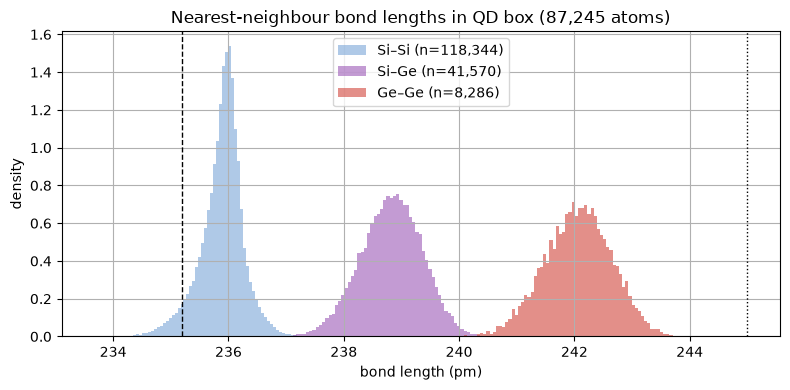


[해석] 확인할 점: 결합 길이가 모두 한 값이면 이완이 안 된 구조입니다. 이완됐다면 Si–Si < Si–Ge < Ge–Ge 순서로 갈라지고, 각각 벌크 값에서 서로 쪽으로 끌려 있습니다. 우물(Si–Si만)과 장벽(Si–Si)의 결합 길이 차이가 우물이 받는 변형의 크기입니다.


In [17]:
# [점검] 결합 길이 분포 (양자점 상자 안, 결합 종류·영역별)
if TB_READY:
    qd = ((pos[:, 0] >= QD_BOX_NM["x"][0]) & (pos[:, 0] <= QD_BOX_NM["x"][1])
          & (pos[:, 1] >= QD_BOX_NM["y"][0]) & (pos[:, 1] <= QD_BOX_NM["y"][1])
          & (pos[:, 2] >= QD_BOX_NM["z"][0]) & (pos[:, 2] <= QD_BOX_NM["z"][1]))
    pq, gq = pos[qd], is_ge[qd]
    bi, bj, bd = neighbor_bonds(pq, k=4, r_max=0.30)
    n_ge_pair = gq[bi].astype(int) + gq[bj].astype(int)
    btype = np.array(["Si–Si", "Si–Ge", "Ge–Ge"])[n_ge_pair]
    zmid = 0.5 * (pq[bi, 2] + pq[bj, 2])
    region = np.where((zmid < WELL_TOP_NM - 1) & (zmid > WELL_BOT_NM + 1), "well",
                      np.where((zmid > WELL_TOP_NM + 1) | (zmid < WELL_BOT_NM - 1),
                               "barrier", "interface"))
    bond_df = pd.DataFrame({"type": btype, "region": region, "d_nm": bd})
    tbl = bond_df.groupby(["region", "type"])["d_nm"].agg(["count", "mean", "std"])
    tbl["mean_pm"] = tbl["mean"] * 1e3
    tbl["std_pm"] = tbl["std"] * 1e3
    display(tbl[["count", "mean_pm", "std_pm"]].round(2))
    print("벌크 기준: Si–Si 235.2 pm, Ge–Ge 245.0 pm")

    fig, ax = plt.subplots(figsize=(8, 4))
    for t, c in (("Si–Si", SI_COLOR), ("Si–Ge", "#9b59b6"), ("Ge–Ge", GE_COLOR)):
        d_ = bond_df.loc[bond_df["type"] == t, "d_nm"] * 1e3
        if len(d_):
            ax.hist(d_, bins=80, alpha=0.6, color=c, label=f"{t} (n={len(d_):,})", density=True)
    for ref, ls in ((235.2, "--"), (245.0, ":")):
        ax.axvline(ref, color="k", ls=ls, lw=1)
    ax.set_xlabel("bond length (pm)"); ax.set_ylabel("density")
    ax.set_title(f"Nearest-neighbour bond lengths in QD box ({qd.sum():,} atoms)")
    ax.legend(); ax.grid(True)
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(TB_EXPORT / "analysis_tb_bond_lengths.png", dpi=150)
    plt.show()

    print("\n[해석] 확인할 점: 결합 길이가 모두 한 값이면 이완이 안 된 구조입니다. 이완됐다면 "
          "Si–Si < Si–Ge < Ge–Ge 순서로 갈라지고, 각각 벌크 값에서 서로 쪽으로 끌려 있습니다. "
          "우물(Si–Si만)과 장벽(Si–Si)의 결합 길이 차이가 우물이 받는 변형의 크기입니다.")

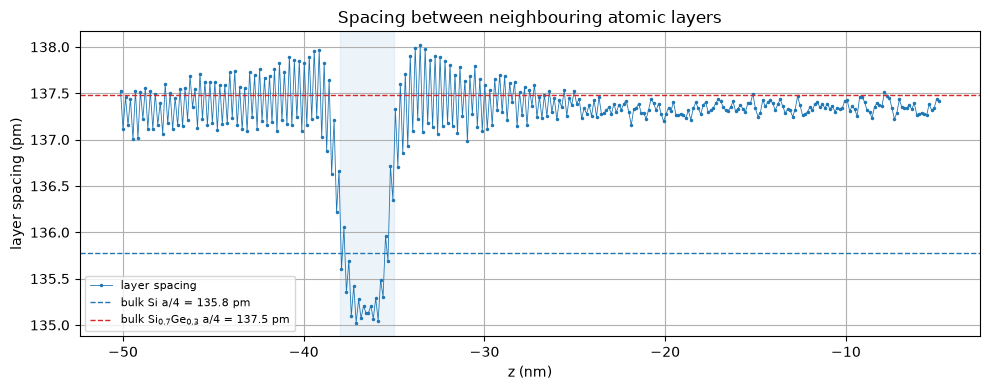

우물 평균 층간격   : 135.20 pm  (벌크 Si 대비 -0.43 %)
스페이서 평균 층간격: 137.38 pm  (벌크 SiGe 대비 -0.07 %)

[해석] 우물과 장벽의 층간격 차이가 튜토리얼 VESTA 그림의 'SiGe 층 부풂'입니다. 실제 Si/SiGe 웨이퍼에서는 Si 우물이 이완된 SiGe 버퍼 위에서 면내로 늘어나고(인장 변형) z로는 줄어듭니다. 이 튜토리얼 상자의 경계 조건에서 어느 쪽에 가까운지 이 숫자로 확인하세요.


In [18]:
# [점검] 원자층 간격 vs z (SiGe 층의 늘어남 = 변형)
if TB_READY:
    dz_layer = np.diff(layer_z)
    z_mid = 0.5 * (layer_z[1:] + layer_z[:-1])
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(z_mid, dz_layer * 1e3, ".-", ms=3, lw=0.6, label="layer spacing")
    ax.axhline(A_SI / 4 * 1e3, color="tab:blue", ls="--", lw=1, label=f"bulk Si a/4 = {A_SI/4*1e3:.1f} pm")
    ax.axhline(A_SIGE / 4 * 1e3, color="tab:red", ls="--", lw=1,
               label=f"bulk Si$_{{0.7}}$Ge$_{{0.3}}$ a/4 = {A_SIGE/4*1e3:.1f} pm")
    ax.axvspan(WELL_BOT_NM, WELL_TOP_NM, color="tab:blue", alpha=0.08)
    ax.set_xlabel("z (nm)"); ax.set_ylabel("layer spacing (pm)")
    ax.set_title("Spacing between neighbouring atomic layers")
    ax.legend(fontsize=8); ax.grid(True)
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(TB_EXPORT / "analysis_tb_layer_spacing.png", dpi=150)
    plt.show()

    in_w = (z_mid < WELL_TOP_NM - 0.5) & (z_mid > WELL_BOT_NM + 0.5)
    in_b = (z_mid > WELL_TOP_NM + 3) & (z_mid < WELL_TOP_NM + 15)
    sp_w, sp_b = dz_layer[in_w].mean(), dz_layer[in_b].mean()
    print(f"우물 평균 층간격   : {sp_w*1e3:.2f} pm  (벌크 Si 대비 {(sp_w/(A_SI/4)-1)*100:+.2f} %)")
    print(f"스페이서 평균 층간격: {sp_b*1e3:.2f} pm  (벌크 SiGe 대비 {(sp_b/(A_SIGE/4)-1)*100:+.2f} %)")

    print("\n[해석] 우물과 장벽의 층간격 차이가 튜토리얼 VESTA 그림의 'SiGe 층 부풂'입니다. "
          "실제 Si/SiGe 웨이퍼에서는 Si 우물이 이완된 SiGe 버퍼 위에서 면내로 늘어나고(인장 변형) "
          "z로는 줄어듭니다. 이 튜토리얼 상자의 경계 조건에서 어느 쪽에 가까운지 이 숫자로 확인하세요.")

## 11. 스페이서 국소 조성 지도 — 전자가 실제로 느끼는 조성 요동

우물 상부 계면 바로 위 1 nm 두께 스페이서를 1 × 1 nm 셀로 나눠 셀마다 Ge 비율을 구합니다.
셀당 원자는 약 50개라 이항분포만으로도 σ ≈ 6.5 % 요동이 생깁니다. 파동함수가 계면에
닿는 부분에서 이런 국소 요동이 valley splitting을 소자마다 다르게 만듭니다.

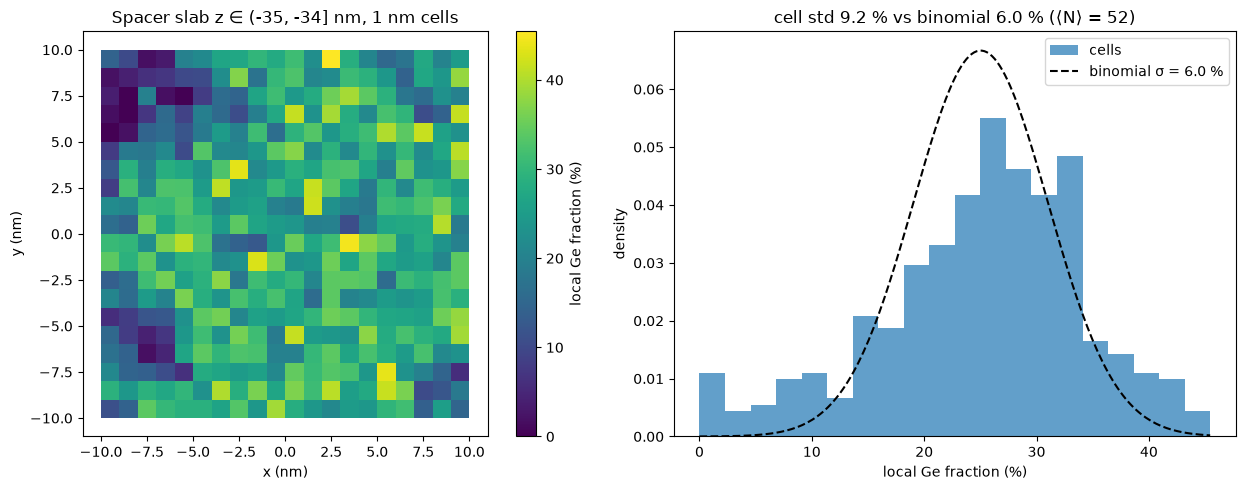

slab 평균 Ge 25.03 % (거친 계면 때문에 30 %보다 낮을 수 있음), 셀 400개, 셀 간 표준편차 9.22 %


In [19]:
# [점검] 스페이서 slab의 xy 국소 Ge 지도 + 히스토그램
if TB_READY:
    SLAB_NM, CELL_NM = 1.0, 1.0
    slab = (pos[:, 2] > WELL_TOP_NM) & (pos[:, 2] <= WELL_TOP_NM + SLAB_NM)
    ex = np.arange(np.floor(pos[:, 0].min()), np.ceil(pos[:, 0].max()) + 1e-9, CELL_NM)
    ey = np.arange(np.floor(pos[:, 1].min()), np.ceil(pos[:, 1].max()) + 1e-9, CELL_NM)
    n_c, _, _ = np.histogram2d(pos[slab, 0], pos[slab, 1], bins=[ex, ey])
    g_c, _, _ = np.histogram2d(pos[slab & is_ge, 0], pos[slab & is_ge, 1], bins=[ex, ey])
    full = n_c >= 0.8 * np.median(n_c[n_c > 0])          # 상자 가장자리의 덜 찬 셀 제외
    with np.errstate(invalid="ignore", divide="ignore"):
        f_c = np.where(full, g_c / n_c, np.nan)

    vals = f_c[np.isfinite(f_c)]
    x_slab = is_ge[slab].mean()
    n_mean = n_c[full].mean()
    s_bin = np.sqrt(x_slab * (1 - x_slab) / n_mean)

    fig, axs = plt.subplots(1, 2, figsize=(13, 5))
    im = axs[0].imshow(f_c.T * 100, origin="lower", cmap="viridis",
                       extent=[ex[0], ex[-1], ey[0], ey[-1]])
    fig.colorbar(im, ax=axs[0], label="local Ge fraction (%)")
    axs[0].set_xlabel("x (nm)"); axs[0].set_ylabel("y (nm)")
    axs[0].set_title(f"Spacer slab z ∈ ({WELL_TOP_NM:g}, {WELL_TOP_NM+SLAB_NM:g}] nm, "
                     f"{CELL_NM:g} nm cells")
    axs[1].hist(vals * 100, bins=20, density=True, alpha=0.7, label="cells")
    xx = np.linspace(vals.min(), vals.max(), 200)
    axs[1].plot(xx * 100, np.exp(-(xx - x_slab)**2 / (2 * s_bin**2)) / (np.sqrt(2*np.pi) * s_bin * 100),
                "k--", label=f"binomial σ = {s_bin*100:.1f} %")
    axs[1].set_xlabel("local Ge fraction (%)"); axs[1].set_ylabel("density")
    axs[1].set_title(f"cell std {vals.std()*100:.1f} % vs binomial {s_bin*100:.1f} % "
                     f"(⟨N⟩ = {n_mean:.0f})")
    axs[1].legend()
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(TB_EXPORT / "analysis_tb_spacer_xy_map.png", dpi=150)
    plt.show()
    print(f"slab 평균 Ge {x_slab*100:.2f} % (거친 계면 때문에 30 %보다 낮을 수 있음), "
          f"셀 {vals.size}개, 셀 간 표준편차 {vals.std()*100:.2f} %")

## 12. 양자점 영역 구성과 TB 결과 정답지 대조

`SubAtoms` 상자(x, y ±8 nm, z −40 ~ −33 nm) 안의 원자 구성을 세고,
`multiscale_params.txt`에 저장된 VS, SOC 행렬원소 C, D_BG를 문서 값과 비교합니다.
(params 파일은 SI 단위: VS·C는 J, D는 J/V)

In [20]:
# [점검] 양자점 상자 원자 구성 + multiscale_params.txt 대조
if TB_READY:
    e_charge = 1.602176634e-19
    print(f"양자점 상자 원자 수 : {qd.sum():,} (튜토리얼 문서: 87,189)")
    print(f"양자점 상자 Ge 비율 : {is_ge[qd].mean()*100:.2f} %")

    ref = {"VS (meV)": 1.4855196868505457, "|C| (µeV)": abs(-1.0363080873666102e-05 + 1.1020782287222193e-05j) * 1e6,
           "D_BG (µeV/V)": 6.115274315887098e-06 * 1e6}
    rows = []
    if FILE_PARAMS.exists():
        txt = [l.strip() for l in FILE_PARAMS.read_text().splitlines() if l.strip()]
        vals_ = [complex(t.replace(" ", "")) for t in txt]
        got = {"VS (meV)": vals_[0].real / e_charge * 1e3,
               "|C| (µeV)": abs(vals_[1]) / e_charge * 1e6,
               "D_BG (µeV/V)": abs(vals_[2]) / e_charge * 1e6}
        for k in ref:
            rows.append({"quantity": k, "this run": got[k], "tutorial doc": ref[k],
                         "diff %": (got[k] - ref[k]) / ref[k] * 100})
        tb_check_df = pd.DataFrame(rows)
        display(tb_check_df.round(4))
    else:
        print(f"[참고] {FILE_PARAMS.name} 없음 — VS 대조는 건너뜀")
        tb_check_df = None

양자점 상자 원자 수 : 87,245 (튜토리얼 문서: 87,189)
양자점 상자 Ge 비율 : 17.51 %


,quantity,this run,tutorial doc,diff %
0,VS (meV),1.4855,1.4855,-0.0004
1,|C| (µeV),15.1283,15.1278,0.0033
2,D_BG (µeV/V),6.1197,6.1153,0.0716


## 13. 최종 요약

In [21]:
# [점검] 핵심 결과 요약 (MVEMT + 원자 구조)
print("=" * 88)
print("QTCAD M07 VALLEY SPLITTING — FINAL SUMMARY")
print("=" * 88)
print("-- 1D MVEMT (continuum, sections 1-6) --")
print(f"E-field range                    : {E_field.min():.1f} - {E_field.max():.1f} MV/m ({len(E_field)} points)")
print(f"Full splitting range              : {vs_full.min()*1e3:.4f} - {vs_full.max()*1e3:.4f} meV")
print(f"ff splitting range                : {vs_ff.min()*1e3:.4f} - {vs_ff.max()*1e3:.4f} meV")
print(f"trivial splitting range           : {vs_trivial.min()*1e3:.4f} - {vs_trivial.max()*1e3:.4f} meV")
print(f"Mean |ff deviation| from full     : {np.mean(np.abs(rel_dev_ff)):.3f} %")
print(f"Mean trivial/full ratio           : {np.mean(ratio_trivial_full):.3f} x")
print(f"Power-law exponent (full)         : E^{p_full:.3f}")
print(f"Power-law exponent (trivial)      : E^{p_trivial:.3f}")
print(f"Median solve time trivial/ff/full: {time_summary.loc['trivial','median']:.1f} / {time_summary.loc['ff','median']:.1f} / {time_summary.loc['full','median']:.1f} s")
print(f"Analysis export directory         : {EXPORT_DIR}")

# [점검] 원자 구조(SiGe Part 2) 핵심 결과 요약
if TB_READY:
    print("-- SiGe Part 2 atomic structure (sections 7-12) --")
    print(f"Atoms (total / QD box)            : {len(species):,} / {qd.sum():,}")
    print(f"Atomic layers detected            : {n_layers}")
    print(f"Barrier Ge (mean, layer std)      : {layer_ge[barrier].mean()*100:.2f} %, "
          f"{layer_ge[barrier].std()*100:.2f} % (binomial {sig_exp.mean()*100:.2f} %)")
    for nm_ in ("top", "bottom"):
        print(f"{nm_:6s} interface z50 / 10–90 width : {iface[nm_]['z50_nm']:.2f} nm / "
              f"{iface[nm_]['width_10_90_nm']:.2f} nm")
    print(f"Ge atoms in well core             : {is_ge[in_well].sum()}")
    print(f"Layer spacing well / spacer       : {sp_w*1e3:.2f} / {sp_b*1e3:.2f} pm")
    print(f"Spacer local Ge std (1 nm cells)  : {vals.std()*100:.2f} % (binomial {s_bin*100:.2f} %)")
    if tb_check_df is not None:
        print(f"VS this run / doc                 : {tb_check_df.iloc[0]['this run']:.4f} / "
              f"{tb_check_df.iloc[0]['tutorial doc']:.4f} meV")
    print(f"Figures saved to                  : {TB_EXPORT}")
    print("=" * 88)


QTCAD M07 VALLEY SPLITTING — FINAL SUMMARY
-- 1D MVEMT (continuum, sections 1-6) --
E-field range                    : 5.0 - 50.0 MV/m (10 points)
Full splitting range              : 0.1049 - 1.0575 meV
ff splitting range                : 0.1030 - 1.0372 meV
trivial splitting range           : 0.5132 - 5.1161 meV
Mean |ff deviation| from full     : 1.852 %
Mean trivial/full ratio           : 4.862 x
Power-law exponent (full)         : E^1.004
Power-law exponent (trivial)      : E^0.999
Median solve time trivial/ff/full: 28.3 / 49.5 / 137.6 s
Analysis export directory         : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M07. Valley splitting\Reference\output
-- SiGe Part 2 atomic structure (sections 7-12) --
Atoms (total / QD box)            : 896,337 / 87,245
Atomic layers detected            : 332
Barrier Ge (mean, layer std)      : 30.07 %, 0.92 % (binomial 0.88 %)
top    interface z50 / 10–90 width : -35.17 nm / 1.53 nm
bottom interface z50 / 10–90 width : -38.1

## 해석 주의사항

- 세 `.txt` 파일의 두 번째 열은 이미 eV 단위입니다 (원본 스크립트에서
  `(d.energies[1] - d.energies[0]) / ct.e`로 저장, J이 아닌 eV로 직접 저장됨).
  이 노트북에서는 가독성을 위해 meV로 추가 변환했습니다.
- `valley_wavefunctions.png`는 스크립트 루프의 **마지막** 소자(가장 마지막
  `approx`/`E` 조합인 `approx=None, E=50 MV/m`)에 대해서만 저장된 그림입니다.
  다른 근사/전기장 조합의 wavefunction은 저장되어 있지 않습니다.
- Trivial 근사의 ~5배 과대평가, ff 근사의 ~2% 이내 일치는 이 특정
  양자우물/전기장 범위에 대한 수치이며, 우물 폭이나 계면 거칠기(disorder)가
  달라지면 정량적인 비율은 달라질 수 있습니다.
- 전기장에 대한 거의 선형인 스케일링($p\approx1$)은 5-50 MV/m 범위 안에서만
  확인된 것이며, 더 넓은 범위에서는 valley splitting이 비단조적으로
  진동할 수 있다는 점에 유의해야 합니다.
- 1D MVEMT에서 갈라지는 valley 쌍은 구속축(1D 메시의 x축)에 따라 정해집니다.
  wavefunction 그림의 해석은 ±x valley 기준입니다 (초판의 ±z 해석은 정정함).
- 결과 `.txt`는 원본 스크립트에서 덧쓰기 모드로 저장됩니다. 수정된 스크립트는
  시작 시 기존 파일을 지우므로 재실행해도 행이 누적되지 않습니다.
- 계산 시간은 로그 3개 중 전체 30점을 끝까지 수행한 `valleysplitting_run3.log`
  기준입니다. run1(점당 420~760 s)은 다른 작업과 동시 실행 등 조건이 달랐던
  것으로 보여 비교에서 제외했습니다.
- 1~6절의 MVEMT 분석은 원자 배치를 다루지 않는 envelope 모델입니다. 원자 배치·격자 구조·
  조성 분포는 7~12절의 SiGe Part 2 TB 결과에서 별도로 분석합니다.
